In [80]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


In [4]:
df = pd.read_csv("../data/20220519_full_mm_gsadk_sdm-1.csv", header=0)

In [5]:
df.head()

,Time [s],Temp. [°C],E1,E2,E3,E4,E5,E6,E7,E8,...,J7,J8,J9,J10,J11,J12,J13,J14,J15,J16
0,0.000,28.7,8949,8905,4657,5286,3665,3320,2898,2503,...,2669,2894,2160,2266,2207,2020,1848,1978,1871,1927
1,65.403,28.6,8812,8714,4534,4977,3458,3189,2793,2487,...,2625,2625,2179,2225,2176,2003,1834,1976,1798,1937
2,130.315,28.5,10990,8623,4486,5012,3441,3172,2705,2445,...,2610,2637,2148,2217,2160,2017,1858,1962,1801,1917
3,195.222,28.5,10716,8684,4564,4966,3502,3174,2688,2447,...,2571,2677,2195,2257,2185,2015,1871,1976,1799,1928
4,260.134,28.5,10289,8625,4538,4931,3409,3195,2709,2418,...,2585,2667,2157,2234,2198,2039,1874,1969,1806,1887


In [10]:
gs_wt_df = df.iloc[:, 70:86].T
gs_wt_df

,0,1,2,3,4,5,6,7,8,9,...,212,213,214,215,216,217,218,219,220,221
I1,9083,9023,9153,9274,9661,9669,9932,10106,10253,10400,...,33652,34103,34096,34315,34488,35055,34266,34077,34697,34728
I2,8401,8388,8637,8701,8880,8939,9227,9417,9669,9810,...,31903,32040,32244,32137,32302,33408,32354,32356,32779,33076
I3,5470,5541,5800,5920,6232,6358,6614,6862,7192,7264,...,30322,30195,30301,30280,30847,30983,30639,30391,30593,31514
I4,5032,5043,5299,5550,5745,5864,6074,6347,6501,6778,...,28970,29294,29405,29264,29589,30059,29211,29613,29414,30037
I5,3789,3917,4087,4287,4443,4600,4767,4958,5152,5261,...,24313,24596,24638,24647,25226,25392,24786,24740,25057,25405
I6,3900,3987,4425,4446,4637,4777,4936,5040,5124,5330,...,24338,24433,24892,24525,24637,25002,24571,24806,24793,25418
I7,3011,3070,3194,3333,3443,3535,3692,3791,3891,4038,...,18587,18818,18648,18610,19017,18932,18832,18648,18905,19222
I8,2872,3011,3067,3260,3394,3549,3658,3829,3910,4100,...,19569,19542,19548,19705,20050,19856,19650,19818,19875,20101
I9,2742,2838,2850,2929,3036,3089,3192,3278,3301,3439,...,14406,14475,14603,14606,14746,14791,14790,14750,14641,14968
I10,2612,2566,2650,2731,2800,2853,2912,2986,3075,3100,...,13527,13775,13834,13830,13867,13953,13877,13766,13862,14036


In [6]:
times = np.tile(df["Time [s]"], (16,1))

In [7]:
times

array([[    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       ...,
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305]])

In [8]:
time_arr = times[0]

In [12]:
gs_wt_arr = np.array(gs_wt_df)

## Trying "Gradient Descent Approach" To Initial Rate

In [17]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

## Wrapping Initial Slope into a Function

In [18]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    for i in range(len(perc_times), min_included_percent, -1):
        curr_times = [item for sublist in perc_times[:i] for item in sublist]
        curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    max_r2_idx = np.argmax(scores)
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]

# Pipeline Function

In [15]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

In [25]:
def get_all_initial_slopes(time_arr: np.array, kinetic_data: np.array, substrate_concs: [int], title: str):
    
    rep_1_arr = kinetic_data[0::2]
    rep_2_arr = kinetic_data[1::2]
    
    rep_1_slopes = []
    rep_2_slopes = []

    fig = plt.figure(figsize=(10,10)) 
    for data, sub_conc in zip(rep_1_arr, sub_concs):
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        rep_1_slopes.append(slope)
        plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
        plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    plt.title(f"{title} Replicate 1")
    plt.xlabel("Time (seconds)")
    plt.ylabel("µM")
    plt.legend() 
    
    fig = plt.figure(figsize=(10,10)) 
    for data, sub_conc in zip(rep_2_arr, sub_concs):
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        plt.scatter(time_arr, data)
        rep_2_slopes.append(slope)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
        plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    plt.title(f"{title} Replicate 2")
    plt.xlabel("Time (seconds)")
    plt.ylabel("µM")
    plt.legend() 
    plt.show()
    return rep_1_slopes, rep_2_slopes

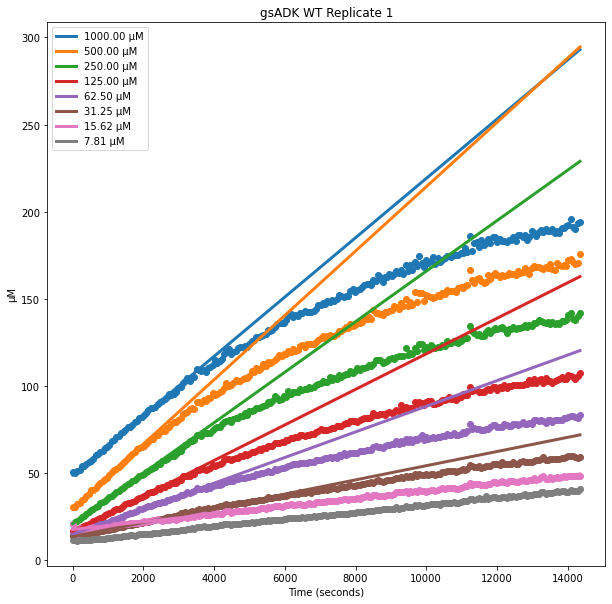

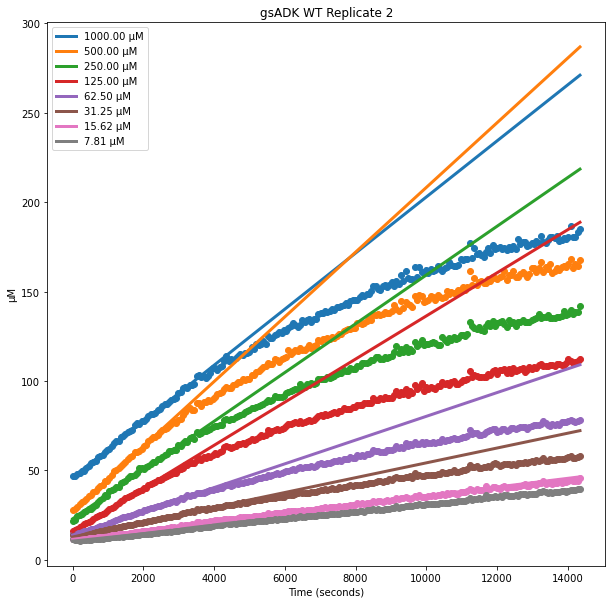

In [27]:
gsADK_wt_r1_slopes, gsADK_wt_r2_slopes = get_all_initial_slopes(time_arr, gs_wt_arr / 179, sub_concs, "gsADK WT")

# Micheaelis Menten Pipeline

In [35]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [51]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.mean([rep_1_slopes, rep_2_slopes], axis=0)
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.std([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 1000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

In [31]:
e_conc = .652 * 1e-4

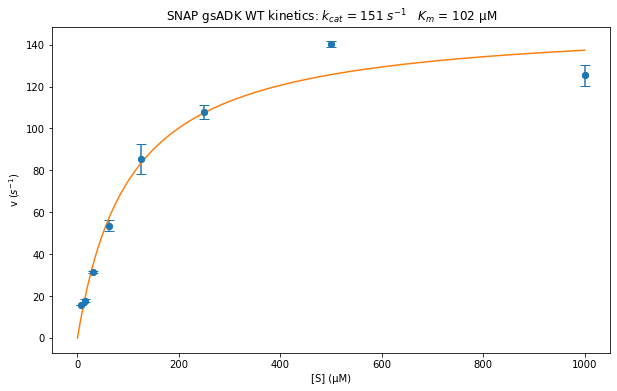

In [36]:
fit_and_plot_micheaelis_menten(gsADK_wt_r1_slopes, gsADK_wt_r2_slopes, sub_concs, .652 * 2e-4, "SNAP gsADK WT")

# gsADK I111L Plotting

In [37]:
gs_i111l_df = df.iloc[:, 19:35]
gs_i111l_arr = np.array(gs_i111l_df).T

In [109]:
gs_i111l_conc = .618 * 1e-4

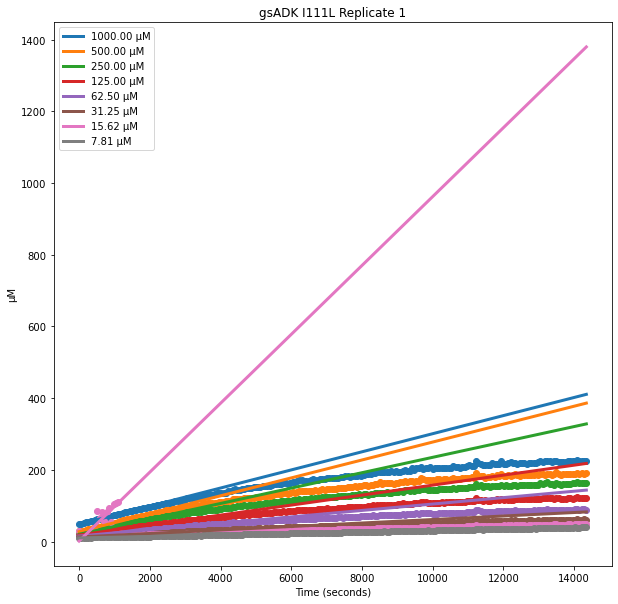

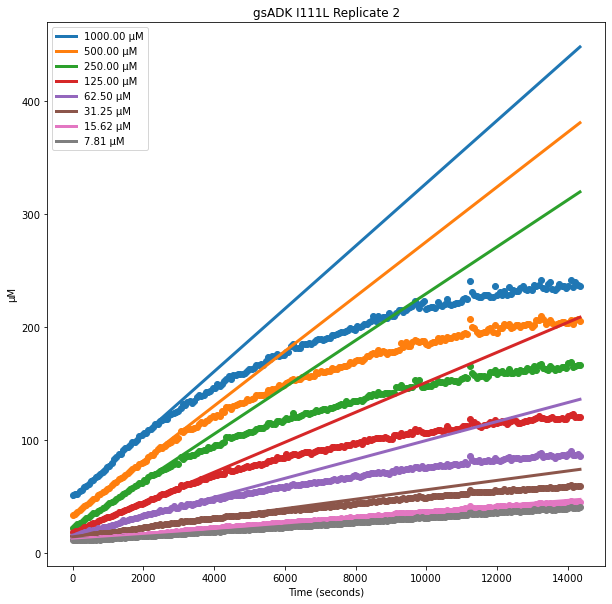

In [38]:
gsADK_i111l_r1_slopes, gsADK_i111l_r2_slopes = get_all_initial_slopes(time_arr, gs_i111l_arr / 179, sub_concs, "gsADK I111L")

In [40]:
gsADK_i111l_r1_slopes[6] =  gsADK_i111l_r2_slopes[6]

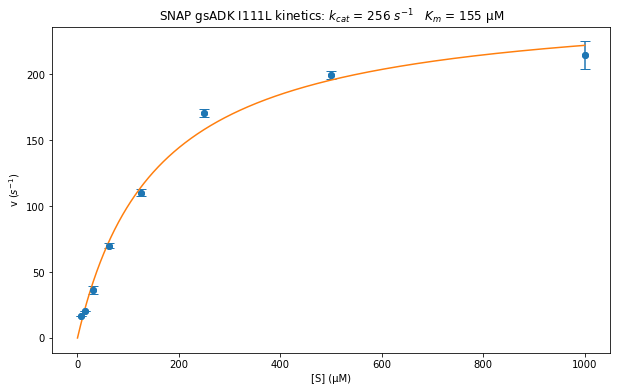

In [42]:
fit_and_plot_micheaelis_menten(gsADK_i111l_r1_slopes, gsADK_i111l_r2_slopes, sub_concs, .618 * 2e-4, "SNAP gsADK I111L")

# Computing Background Rates

In [47]:
no_enz_df = df.iloc[:, 87:103]
no_enz_arr = np.array(no_enz_df).T

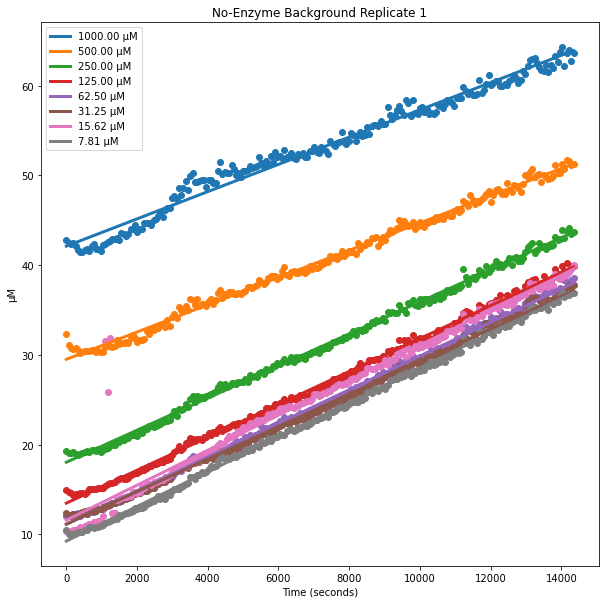

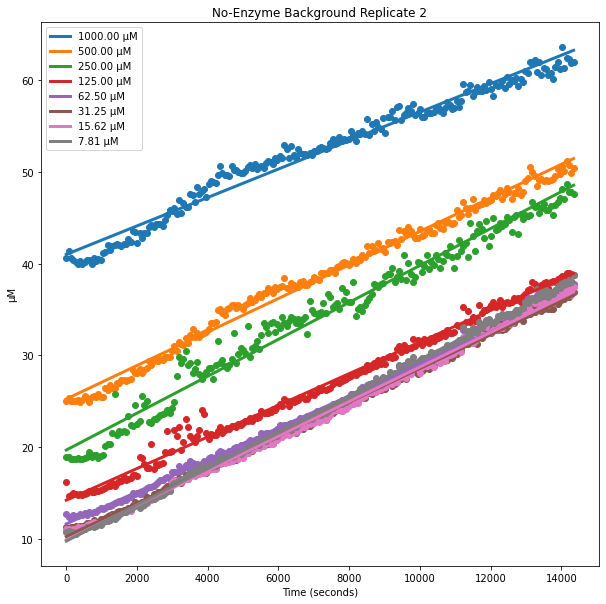

In [48]:
no_enz_r1_slopes, no_enz_r2_slopes = get_all_initial_slopes(time_arr, no_enz_arr / 179, sub_concs, "No-Enzyme Background")

# Redoing WT and I111L

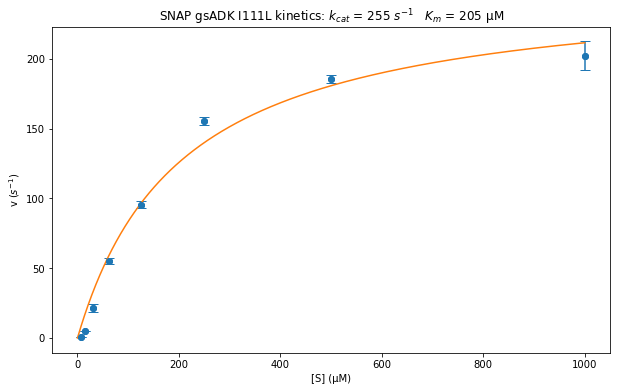

In [52]:
fit_and_plot_micheaelis_menten(gsADK_i111l_r1_slopes, gsADK_i111l_r2_slopes, sub_concs, .618 * 2e-4, "SNAP gsADK I111L", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

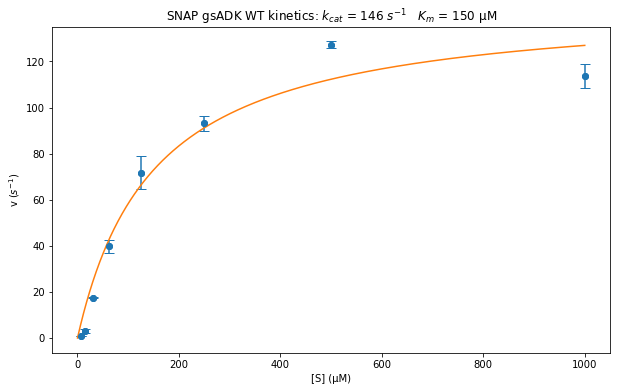

In [53]:
fit_and_plot_micheaelis_menten(gsADK_wt_r1_slopes, gsADK_wt_r2_slopes, sub_concs, .652 * 2e-4, "SNAP gsADK WT", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

# P181A

In [60]:
gs_P181A_df = df.iloc[:, 53:69]
gs_P181A_arr = np.array(gs_P181A_df).T

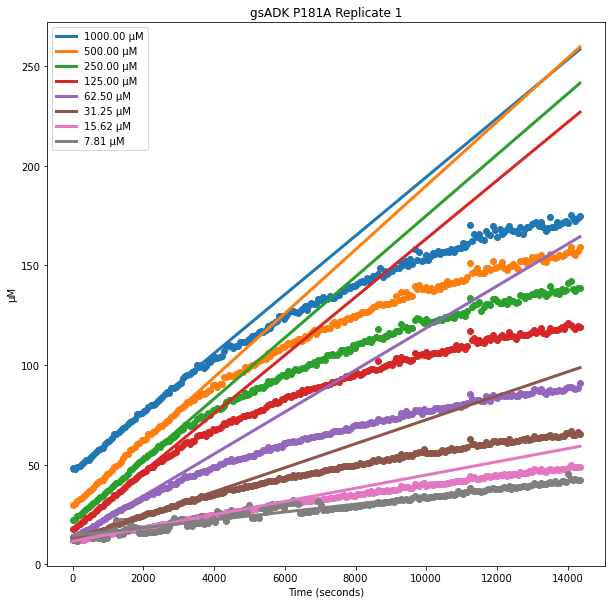

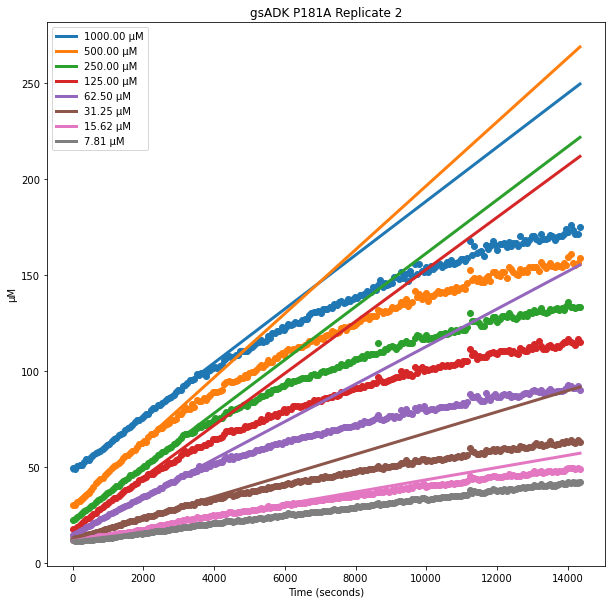

In [61]:
gsADK_p181a_r1_slopes, gsADK_p181a_r2_slopes = get_all_initial_slopes(time_arr, gs_P181A_arr / 179, sub_concs, "gsADK P181A")

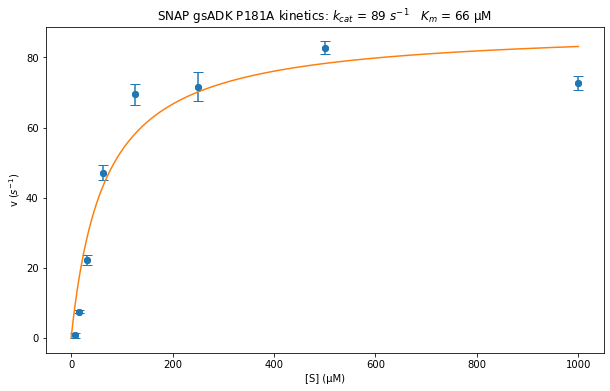

In [62]:
fit_and_plot_micheaelis_menten(gsADK_p181a_r1_slopes, gsADK_p181a_r2_slopes, sub_concs, .885 * 2e-4, "SNAP gsADK P181A", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

# Q16F

In [66]:
gs_Q16F_df = df.iloc[:, 36:52]
gs_Q16F_arr = np.array(gs_Q16F_df).T

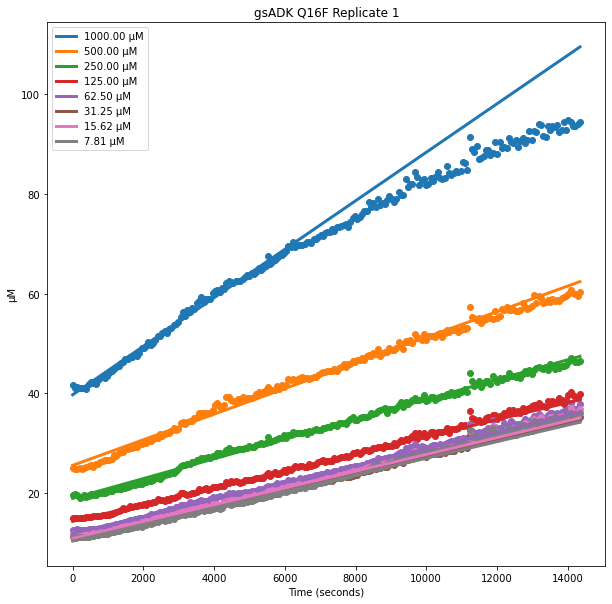

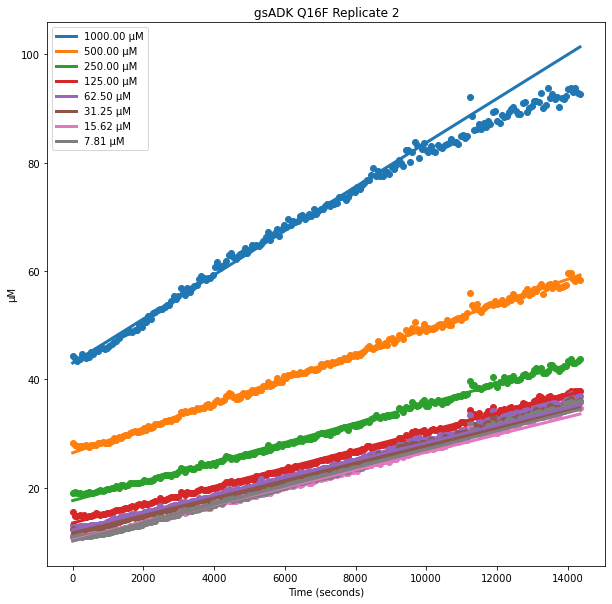

In [68]:
gsADK_q16f_r1_slopes, gsADK_q16f_r2_slopes = get_all_initial_slopes(time_arr, gs_Q16F_arr / 179, sub_concs, "gsADK Q16F")

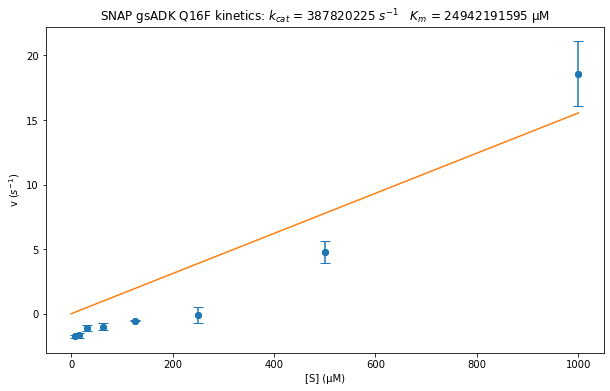

In [69]:
fit_and_plot_micheaelis_menten(gsADK_q16f_r1_slopes, gsADK_q16f_r2_slopes, sub_concs, .789 * 2e-4, "SNAP gsADK Q16F", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

# R88G

In [73]:
gs_r88g_df = df.iloc[:, 2:18]
gs_r88g_arr = np.array(gs_r88g_df).T

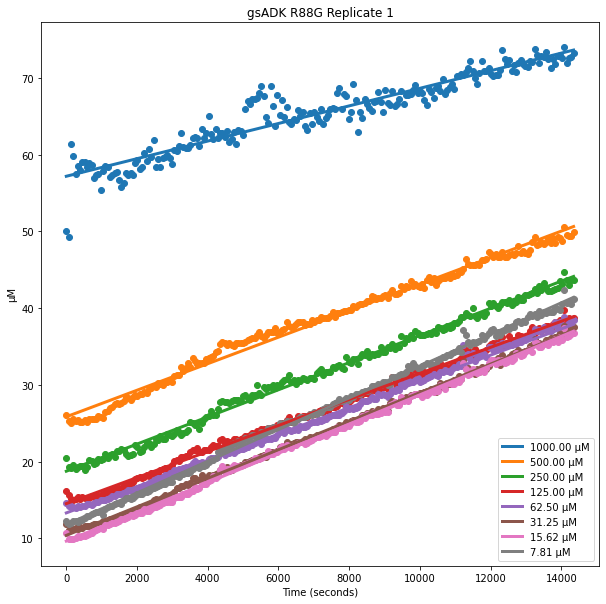

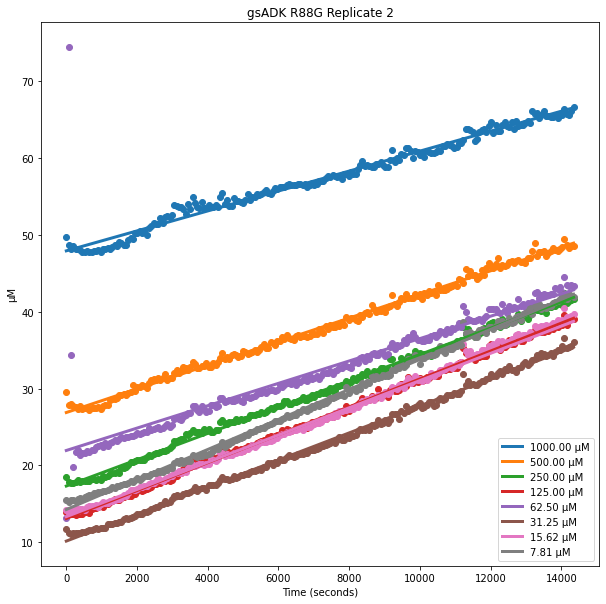

In [74]:
gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes = get_all_initial_slopes(time_arr, gs_r88g_arr / 179, sub_concs, "gsADK R88G")

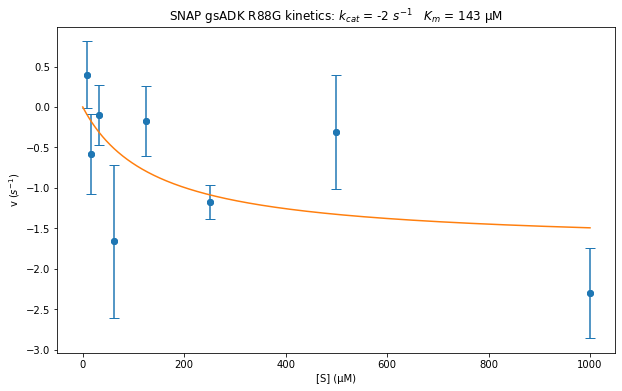

In [75]:
fit_and_plot_micheaelis_menten(gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes, sub_concs, .681 * 2e-4, "SNAP gsADK R88G", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

# MultiMM Plots

In [100]:
def multi_mm_plots(samples: [(np.array, np.array, float, str)], sub_concs: [int], title: str, cmap_bound: (int, int) = (0,1), background_rates: np.array = None,):
    plt.figure(figsize=(10,10))
    cmap = cm.get_cmap('plasma')

    color_vals = np.linspace(cmap_bound[0], cmap_bound[1], len(samples))
    print(len(samples))
    for sample, color_val in zip(samples, color_vals):
        rep_1_slopes, rep_2_slopes, e_conc, label = sample
        avg_slopes = np.mean([rep_1_slopes, rep_2_slopes], axis=0)
        if background_rates is not None:
            avg_slopes -= background_rates
        errs = np.std([rep_1_slopes, rep_2_slopes], axis=0) 
        params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))


        plt.scatter(sub_concs, avg_slopes/e_conc, color=cmap(color_val))
        plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5, color=cmap(color_val))
        x = np.linspace(0, 1000, 1000)
        k_cat = f"{params[0] / e_conc:.0f}"
        K_m = f"{params[1]:.0f}"
        prop_label = label + ": $k_{cat}$=" + k_cat + " $s^{-1}$ " + f"  $K_m$=" +  K_m + " µM"
        plt.plot(x, mm_model(x, params[0], params[1]) / e_conc, color=cmap(color_val), label=prop_label)
        plt.legend()
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title)

3


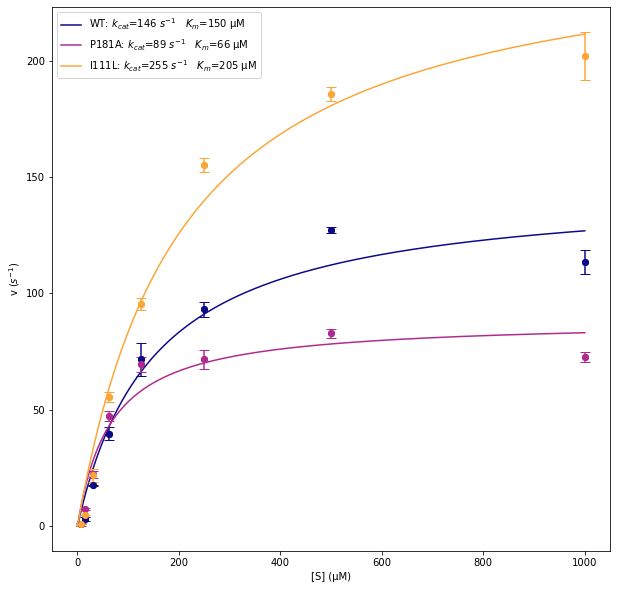

In [102]:
multi_mm_plots([(gsADK_wt_r1_slopes, gsADK_wt_r2_slopes, .652*2e-4,"WT"),
                (gsADK_p181a_r1_slopes, gsADK_p181a_r2_slopes, .885*2e-4, "P181A"),
                (gsADK_i111l_r1_slopes, gsADK_i111l_r2_slopes, .618*2e-4, "I111L")],
               sub_concs, "gsADK MM Kinetics", cmap_bound = (0,0.8), background_rates=np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))